# Post-Processing — Liver Segmentation

**Objectif :** Supprimer les faux positifs de la prédiction U-Net en ne gardant que la plus grande composante connexe (le foie).

**Pipeline :**
1. Imports & configuration
2. Chargement des données + modèle
3. Prédiction brute
4. Post-processing (composantes connexes)
5. Calcul du Dice Score avant / après
6. Visualisation finale

In [15]:
# ── Cellule 1 — Variable d'environnement (toujours en premier) ──────────────
# Résout le conflit entre Intel OpenMP et LLVM OpenMP sur Windows
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

In [16]:
# ── Cellule 2 — Imports ──────────────────────────────────────────────────────
import numpy as np
import torch
import nibabel as nib
import matplotlib.pyplot as plt
from scipy import ndimage          # composantes connexes pour le post-processing

from monai.networks.nets import UNet
from monai.networks.layers import Norm
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    ScaleIntensityRanged,
    Resized,
    ToTensord,
    Spacingd,
    CropForegroundd,
    Orientationd,
)
from monai.data import Dataset, DataLoader

In [17]:
# ── Cellule 3 — Chemins des fichiers ─────────────────────────────────────────
model_dir= 'C:/Users/rowan/Desktop/Projets/Liver Segmentation/Liver_Segmentation/results/best_metric_model.pth'
Test_image= 'C:/Users/rowan/Desktop/Projets/Liver Segmentation/Liver_Segmentation/sample_data/val_images/liver_0_0.nii'
Test_label= 'C:/Users/rowan/Desktop/Projets/Liver Segmentation/Liver_Segmentation/sample_data/val_labels/liver_0_0_0.nii'

In [18]:
# ── Cellule 4 — Pipeline de transforms MONAI ─────────────────────────────────
PostProcessing_transforms = Compose([
            LoadImaged(keys=['image', 'label']),
            EnsureChannelFirstd(keys=['image', 'label']), #AddChannelId does not exist anymore => replaced by EnsureChannelFirstd
            Spacingd(keys =['image','label'], pixdim = (1.5,1.5,1.0), mode =("bilinear","nearest")),
            Orientationd(keys=['image','label'], axcodes="RAS"),
            ScaleIntensityRanged(keys=['image'], a_min=-200, a_max=200, b_min=0.0,  b_max=1.0,clip=True),
            CropForegroundd(keys=['image','label'], source_key='image'),
            Resized(keys=['image','label'],spatial_size=[128, 128, 64]),
            ToTensord(keys=['image', 'label']),                    
])

C:\Users\rowan\anaconda\envs\dicom_env\lib\site-packages\monai\utils\deprecate_utils.py:321: FutureWarning: monai.transforms.croppad.dictionary CropForegroundd.__init__:allow_smaller: Current default value of argument `allow_smaller=True` has been deprecated since version 1.2. It will be changed to `allow_smaller=False` in version 1.5.
  warn_deprecated(argname, msg, warning_category)


In [19]:
# ── Cellule 5 — Dataset & DataLoader ─────────────────────────────────────────
test_files= [{"image": Test_image, "label": Test_label}]
test_ds= Dataset(data=test_files, transform=PostProcessing_transforms)
test_loader= DataLoader(test_ds, batch_size=1)

In [20]:
# ── Cellule 6 — Chargement du modèle ─────────────────────────────────────────
device = torch.device("cpu")  # pas de GPU NVIDIA disponible (Intel Iris Plus)

# Architecture identique à celle utilisée pendant l'entraînement
model = UNet(
    spatial_dims=3,                    
    in_channels=1,                     
    out_channels=2,                    
    channels=(16, 32, 64, 128, 256),   
    strides=(2, 2, 2, 2),              
    num_res_units=2,                   
    norm=Norm.BATCH,                  
).to(device)

model.load_state_dict(torch.load(model_dir, map_location=device, weights_only=True))
model.eval()

UNet(
  (model): Sequential(
    (0): ResidualUnit(
      (conv): Sequential(
        (unit0): Convolution(
          (conv): Conv3d(1, 16, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
          (adn): ADN(
            (N): BatchNorm3d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (D): Dropout(p=0.0, inplace=False)
            (A): PReLU(num_parameters=1)
          )
        )
        (unit1): Convolution(
          (conv): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (adn): ADN(
            (N): BatchNorm3d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (D): Dropout(p=0.0, inplace=False)
            (A): PReLU(num_parameters=1)
          )
        )
      )
      (residual): Conv3d(1, 16, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
    )
    (1): SkipConnection(
      (submodule): Sequential(
        (0): ResidualUnit(
          (conv): Sequential(


In [21]:
# ── Cellule 7 — Prédiction brute ─────────────────────────────────────────────
with torch.no_grad():  # désactive les gradients 
    for batch in test_loader:
        image = batch["image"].to(device)  
        label = batch["label"].to(device)

        output = model(image)

        pred = torch.sigmoid(output)
        pred = (pred[0, 1] > 0.5).cpu().numpy()  
        gt = (label[0, 0] > 0.01).cpu().numpy()
        image_np = image[0, 0].cpu().numpy()
        label_np = label[0, 0].cpu().numpy()

        break
print(f"Shape prédiction : {pred.shape}")
print(f"Voxels prédits comme foie : {pred.sum()}")

Shape prédiction : (128, 128, 64)
Voxels prédits comme foie : 142448


In [22]:
# ── Cellule 8 — Post-processing : composantes connexes ───────────────────────
labeled_array, num_features = ndimage.label(pred)
print(f"Nombre de composantes détectées : {num_features}")
component_sizes = ndimage.sum(pred, labeled_array, range(1, num_features + 1))

largest_component = np.argmax(component_sizes) + 1  
pred_clean = (labeled_array == largest_component)

print(f"Voxels avant post-processing : {pred.sum()}")
print(f"Voxels après post-processing : {pred_clean.sum()}")

Nombre de composantes détectées : 285
Voxels avant post-processing : 142448
Voxels après post-processing : 84527


In [23]:
# ── Cellule 9 — Dice Score avant / après post-processing ─────────────────────
def dice_score(pred, gt):
    """Calcule le Dice Score entre deux masques binaires numpy.
    Formule : (2 × |A ∩ B|) / (|A| + |B|)
    Valeurs : 0.0 (aucun chevauchement) → 1.0 (superposition parfaite)
    """
    intersection = (pred & gt).sum()  # & = AND logique → voxels en commun
    return (2.0 * intersection) / (pred.sum() + gt.sum())

# On compare dans le même espace (128x128x64) avec le gt du pipeline
dice_avant = dice_score(pred.astype(bool), gt.astype(bool))
dice_apres = dice_score(pred_clean.astype(bool), gt.astype(bool))

print(f"Dice avant post-processing : {dice_avant:.4f}")
print(f"Dice après post-processing : {dice_apres:.4f}")
print(f"Amélioration               : +{(dice_apres - dice_avant):.4f}")

Dice avant post-processing : 0.4999
Dice après post-processing : 0.7163
Amélioration               : +0.2163


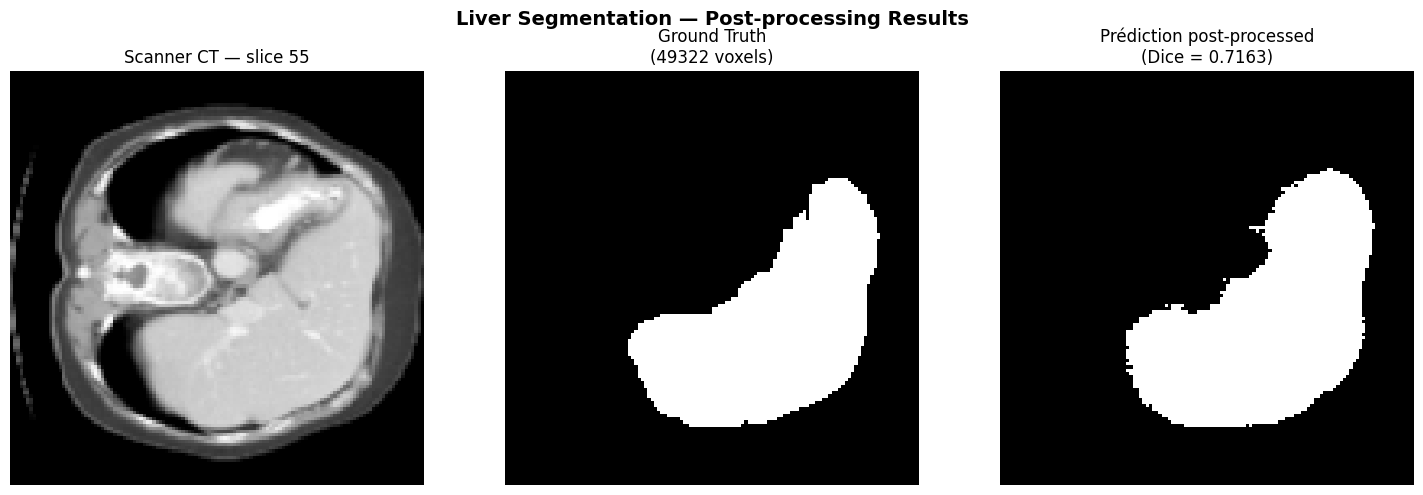

In [24]:
# ── Cellule 10 — Visualisation finale ────────────────────────────────────────
slice_idx = 55

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Scanner CT original
axes[0].imshow(image_np[:, :, slice_idx], cmap="gray")
axes[0].set_title(f"Scanner CT — slice {slice_idx}")
axes[0].axis("off")

# Ground truth
axes[1].imshow(gt[:, :, slice_idx], cmap="gray")
axes[1].set_title(f"Ground Truth\n({gt.sum()} voxels)")
axes[1].axis("off")

# Prédiction après post-processing
axes[2].imshow(pred_clean[:, :, slice_idx], cmap="gray")
axes[2].set_title(f"Prédiction post-processed\n(Dice = {dice_apres:.4f})")
axes[2].axis("off")

plt.suptitle("Liver Segmentation — Post-processing Results", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../results/plots/postprocessing_result.png", dpi=150, bbox_inches="tight")
plt.show()